# **Deep Learning Project**
# ***Predicting if a bank customer will exit the bank***

### Importing the libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import wandb

from sklearn.metrics import classification_report, roc_curve, confusion_matrix
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from wandb.integration.keras import WandbMetricsLogger

### Login to W&B

In [ ]:
wandb.login()

### Importing the dataset

In [3]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1].values
y = dataset.iloc[:, -1].values

In [4]:
#print(X)
#print(y)

## **Data preprocessing**

### Splitting the data into train & test

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Replace missing data

In [6]:
from sklearn.impute import SimpleImputer

numerical_columns = [0, 3, 4, 5, 6, 9]
categorical_columns = [1, 2, 7, 8]

imputer = SimpleImputer(missing_values=np.nan, strategy="median")
imputer.fit(X_train[:, numerical_columns])
X_train[:, numerical_columns] = imputer.transform(X_train[:, numerical_columns])
X_test[:, numerical_columns] = imputer.transform(X_test[:, numerical_columns])

imputer = SimpleImputer(missing_values=np.nan, strategy="most_frequent")
imputer.fit(X_train[:, categorical_columns])
X_train[:, categorical_columns] = imputer.transform(X_train[:, categorical_columns])
X_test[:, categorical_columns] = imputer.transform(X_test[:, categorical_columns])


### One-hot encoding the geography  & gender column

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer(
    transformers=[("encoder", OneHotEncoder(sparse_output=False), [1, 2])],
    remainder="passthrough",
)
X_train = np.array(ct.fit_transform(X_train))
X_test = np.array(ct.transform(X_test))

### Feature scaling

In [8]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## **Seperating the validation set**

In [9]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# print("Train split:", X_tr.shape, y_tr.shape)
# print("Val split:", X_val.shape, y_val.shape)

## **Building the Nerual Network**

A feedforward neural network is constructed with:

*   Two hidden layers (both 6 neurons) using ReLU activation function.
*   One output layer with Sigmoid activation function for binary classification.

ReLU is used to introduce non-linearity, while Sigmoid outputs probabilities between 0 and 1.

### Initializing the ANN

In [10]:
model = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [ ]:
model.add(tf.keras.layers.Dense(6, activation="relu", input_shape=(X_train.shape[1],)))

### Adding the second hidden layer

In [12]:
model.add(tf.keras.layers.Dense(6, activation="relu"))

### Adding the output layer

In [13]:
model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

### Handling Class Imbalance

In this step, we address the class imbalance problem by applying **class weights** technique:

We calculate class weights to give higher importance to the minority class (churn), ensuring the model doesn't ignore churn customers.

it will help improve recall for the churn class.


In [14]:
class_weights = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
class_weight_dict = dict(zip(np.unique(y_tr), class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {np.int64(0): np.float64(0.6279434850863422), np.int64(1): np.float64(2.4539877300613497)}


## **Training the ANN**


### Compiling the ANN

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

### Callbacks - Saving checkpoint


In [16]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
)

### Experiment Tracking with Weights & Biases (W&B)

In [17]:
RUN_NAME = "model_2_exp_4"

wandb.init(
    entity="arminfakhar1384-",
    project="bank_customers_churn",
    name=RUN_NAME,
    config={
        "model_id": 24,
        "architecture": "6-6-relu + sigmoid",
        "epochs": 100,
        "batch_size": 32,
        "learning_rate": 0.001,
        "optimizer": "adam",
        "loss": "binary_crossentropy",
        "class_weight": "balanced"
    }
)

wandb_callback = WandbMetricsLogger()

### Training the ANN on the Training set

The model is trained for up to 100 epochs with a batch size of 32.
A validation split is used to monitor generalization performance during training.

In [ ]:
history = model.fit(
    X_tr,
    y_tr,
    validation_data=(X_val, y_val), # we seperate val_datas
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[checkpoint, wandb_callback],
    verbose=1
)


Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.6536 - auc: 0.4886 - loss: 0.7422 - precision: 0.1948 - recall: 0.2315 - val_accuracy: 0.5481 - val_auc: 0.5505 - val_loss: 0.6726 - val_precision: 0.2412 - val_recall: 0.5675
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5510 - auc: 0.5788 - loss: 0.6747 - precision: 0.2320 - recall: 0.5537 - val_accuracy: 0.4800 - val_auc: 0.6228 - val_loss: 0.6898 - val_precision: 0.2408 - val_recall: 0.7209
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5253 - auc: 0.6612 - loss: 0.6582 - precision: 0.2629 - recall: 0.7527 - val_accuracy: 0.5537 - val_auc: 0.6860 - val_loss: 0.6587 - val_precision: 0.2728 - val_recall: 0.7147
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5938 - auc: 0.7266 - loss: 0.6209 - precision: 0.2970 - recall: 0.7617 - val_accuracy: 0.6031 - val_auc: 0.7251 - val_loss: 0.6376 - val_precision: 0.3057 - val_recall: 0.7454
Epoch 5/100
200/200 ━━━━━━━━

### Find best threshold

In [19]:
val_probs = model.predict(X_val).ravel()

thresholds = np.linspace(0.01, 0.99, 99)
f1s, precs, recs = [], [], []

for t in thresholds:
    val_pred = (val_probs >= t).astype(int)
    f1s.append(f1_score(y_val, val_pred))                 # binary F1 (class 1)
    precs.append(precision_score(y_val, val_pred, zero_division=0))
    recs.append(recall_score(y_val, val_pred, zero_division=0))

best_idx = int(np.argmax(f1s))
best_t = float(thresholds[best_idx])

print("Best threshold (val):", best_t)
print("Val F1:", f1s[best_idx])
print("Val Precision:", precs[best_idx])
print("Val Recall:", recs[best_idx])


50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Best threshold (val): 0.6
Val F1: 0.5873261205564142
Val Precision: 0.5919003115264797
Val Recall: 0.5828220858895705


#### Visualizing:

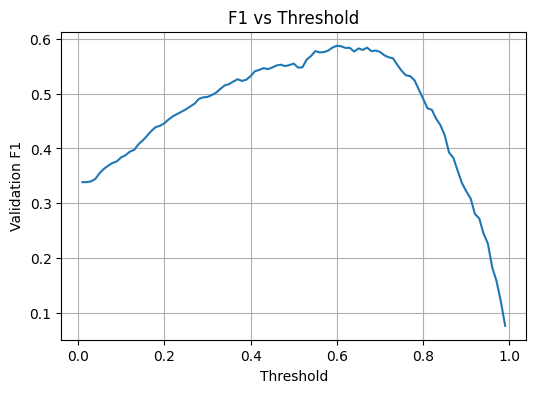

In [20]:
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1s)
plt.xlabel("Threshold")
plt.ylabel("Validation F1")
plt.title("F1 vs Threshold")
plt.grid(True)
plt.show()


### Performance Visualization - Training and Validation Curves


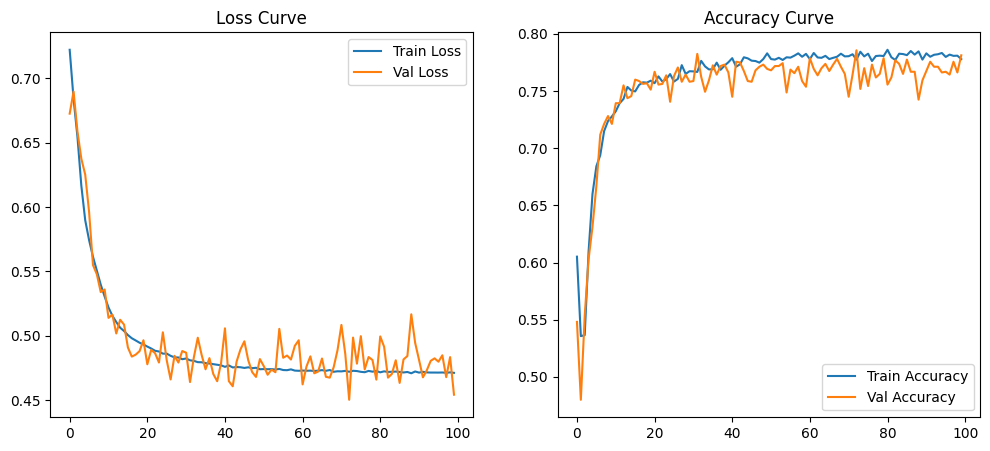

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()

## **Predicting and evaluating the model**

### Confusion Matrix Analysis

In [22]:
test_probs = model.predict(X_test).ravel()
test_pred = (test_probs >= best_t).astype(int)

print("Using threshold:", best_t)
print("Confusion Matrix:\n", confusion_matrix(y_test, test_pred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Using threshold: 0.6
Confusion Matrix:
 [[1414  179]
 [ 158  249]]


**Performance metrics** such as Accuracy, Precision, Recall, F1-score, and AUC are calculated to assess generalization ability.

In [23]:
print("\nClassification Report:\n")
print(classification_report(y_test, test_pred, digits=4))

print("Test ROC-AUC:", roc_auc_score(y_test, test_probs))


Classification Report:

              precision    recall  f1-score   support

           0     0.8995    0.8876    0.8935      1593
           1     0.5818    0.6118    0.5964       407

    accuracy                         0.8315      2000
   macro avg     0.7406    0.7497    0.7450      2000
weighted avg     0.8348    0.8315    0.8331      2000

Test ROC-AUC: 0.843539996082369


### Plotting ROC Curve

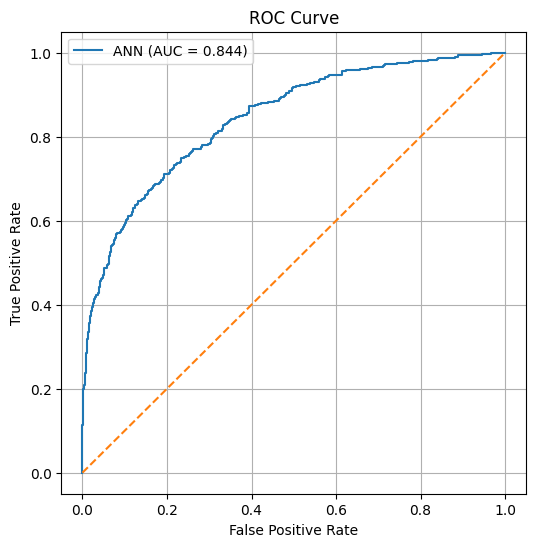

In [24]:
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')  # random classifier

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


## Final Conclusion of the churn prediction experiments

After multiple experiments and adjustments, we have reached a model configuration that provides a strong and well-balanced performance for our churn prediction task.

Due to the inherent class imbalance in the dataset (approximately 80% non-churn and 20% churn), the model initially tended to predict the majority class too frequently. This resulted in poor detection of churned customers and an unsatisfactory trade-off between precision and recall.


To address this issue, we experimented with several strategies:

- Applying class weights to emphasize the churn class

- Modifying the network architecture

- Introducing regularization and early stopping

- Tuning the classification threshold

- Optimizing specifically for F1-score


During earlier experiments, heavily weighting the churn class significantly increased recall. However, this came at the cost of a large number of false positives, which drastically reduced precision. While recall was high, the imbalance between precision and recall led to a suboptimal F1-score.


Since the primary objective of this project was not simply to maximize recall, but rather to maximize the F1-score and achieve a balanced performance between churn and non-churn customers, we shifted our focus toward finding an optimal trade-off between precision and recall.

Through threshold tuning, we achieved:

- Precision (churn class) ≈ 58%

- Recall (churn class) ≈ 61%

- Macro F1-score ≈ 75%

This demonstrates that the model now maintains a solid balance between correctly identifying churn customers and avoiding excessive false positives. The confusion matrix reflects this improvement, showing a more stable balance between false positives and false negatives.

It is important to note that if our objective had been solely to maximize recall (for example, in a scenario where missing a churn customer is extremely costly), we could further increase recall by adjusting the decision threshold. However, this would inevitably reduce precision and disturb the balance we intentionally optimized for.

Given our stated objective of maximizing F1-score and achieving balanced predictive performance under class imbalance, we conclude that the current model has reached a satisfactory and well-justified performance level.
